# Medical Insurance Price Prediction

## Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [4]:
df=pd.read_csv("insurance.csv")

## Exploratory Data Analysis (EDA)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

## Single Variable Linear Regression

In [9]:
X=df[["age"]]
y=df["charges"]

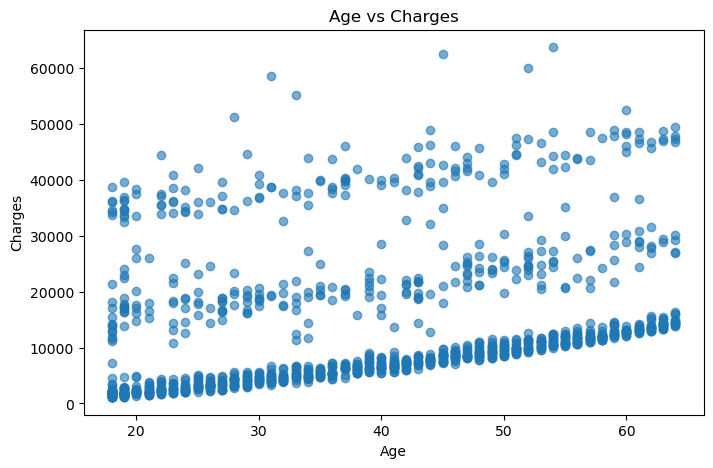

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(X,y,alpha=0.6)
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.show()

In [11]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.4, random_state=42)

In [12]:
model=LinearRegression()

In [13]:
model.fit(X_train,y_train)

LinearRegression()

In [14]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [248.79332501]
Intercept: 3533.712028883214


In [15]:
y_pred=model.predict(X_test)
print(y_pred[:10])

[14729.4116543  12490.27172922 19456.48482947 14978.20497931
  8260.78520406 11992.6850792   8260.78520406 19456.48482947
 10499.92512914 15724.58495434]


In [18]:
comparison=pd.DataFrame({
    "Actual":y_test.values,
    "predicted":y_pred})
print(comparison)

          Actual     predicted
0     9095.06825  14729.411654
1     5272.17580  12490.271729
2    29330.98315  19456.484829
3     9301.89355  14978.204979
4    33750.29180   8260.785204
..           ...           ...
531  13635.63790  18710.104854
532   5966.88740  13983.031679
533   5257.50795  11743.891754
534  10156.78320  15724.584954
535  43921.18370  17466.138229

[536 rows x 2 columns]


## Model Evaluation

In [19]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", MAE)
print("Mean Squared Error:", MSE)
print("Root Mean Squared Error:", RMSE)
print("R² Score:", R2)

Mean Absolute Error: 9157.84460295144
Mean Squared Error: 135232181.05292967
Root Mean Squared Error: 11628.93722800711
R² Score: 0.09334304270459892


## Visualization

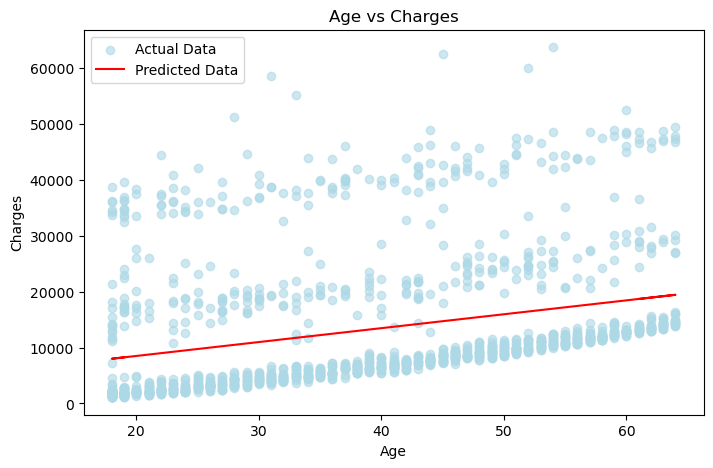

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(X,y,alpha=0.6, color="lightblue", label="Actual Data")
plt.plot(X,model.predict(X), color="red",label="Predicted Data")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.legend()

plt.show()

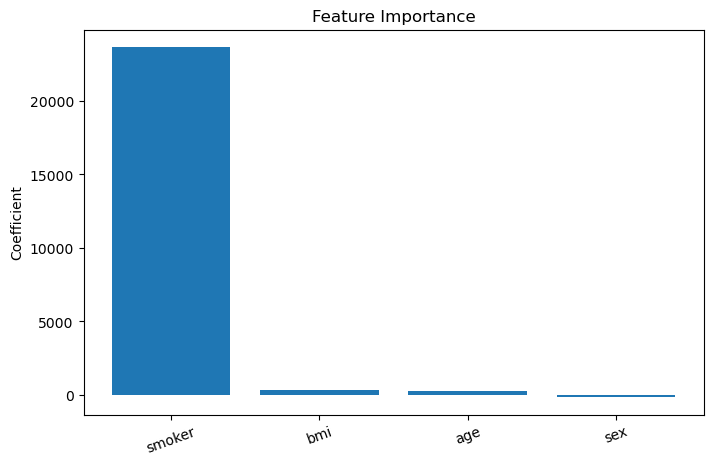

In [180]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
plt.figure(figsize=(8,5))
plt.bar(coefficients["Feature"], coefficients["Coefficient"])
plt.title("Feature Importance")
plt.ylabel("Coefficient")
plt.xticks(rotation=20)
plt.show()

## Data Preprocessing

In [157]:
df["smoker"] = df["smoker"].str.strip().str.lower()

In [158]:
df["smoker"] = df["smoker"].map({ "no": 0, "yes": 1})
df["sex"] = df["sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["region"], drop_first=True)

In [160]:
print(df.isnull().sum())
print(df["smoker"].unique())
print(df["sex"].unique())

print(df.dtypes)

age                 0
sex                 0
bmi                 0
children            0
smoker              0
charges             0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64
[1 0]
[1 0]
age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object


## Multiple Linear Regression

In [26]:
X=df[["age","bmi","sex","smoker"]]
y=df["charges"]

In [162]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [163]:
model=LinearRegression()

In [164]:
model.fit(X_train,y_train)

LinearRegression()

In [186]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_})

coefficients.sort_values(
    by="Coefficient",
    ascending=False)

,Feature,Coefficient
3,smoker,23651.540571
1,bmi,332.336989
0,age,264.307910
2,sex,-156.071212


In [165]:
y_pred=model.predict(X_test)
print(y_pred[:10])

[ 8121.79420391  7353.19572543 37363.48131157  8731.60540916
 27299.01332094 11261.15153038   365.77216016 17530.3655659
  1008.08258299 10503.26156977]


In [181]:
comparison=pd.DataFrame({
    "Actual":y_test.values,
    "predicted":y_pred})
print(comparision)

          Actual     predicted
0     9095.06825   8121.794204
1     5272.17580   7353.195725
2    29330.98315  37363.481312
3     9301.89355   8731.605409
4    33750.29180  27299.013321
..           ...           ...
397   9541.69555  15947.168619
398   4399.73100   7402.919101
399   2200.83085   1995.785085
400  11363.28320  15338.003103
401   1964.78000    614.997733

[402 rows x 2 columns]


## Model Evaluation

In [167]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", MAE)
print("Mean Squared Error:", MSE)
print("Root Mean Squared Error:", RMSE)
print("R² Score:", R2)

Mean Absolute Error: 4207.690697410918
Mean Squared Error: 34444141.49295014
Root Mean Squared Error: 5868.913144096626
R² Score: 0.7650857351850456


## Visualization

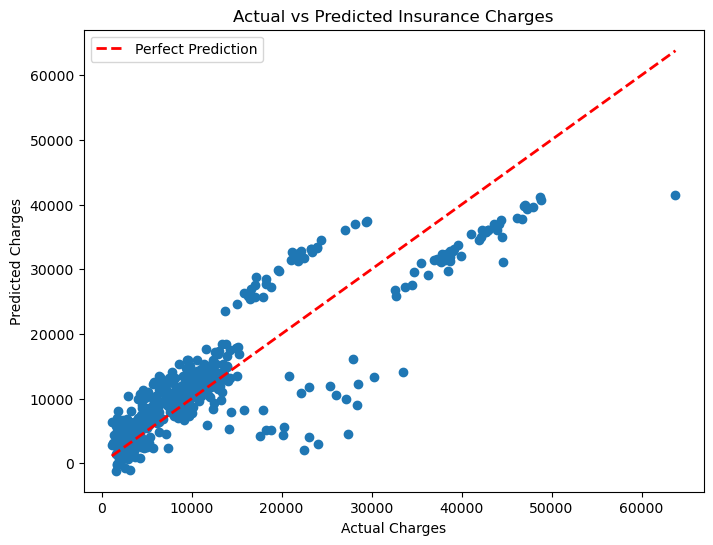

In [184]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot( [y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()
plt.show()

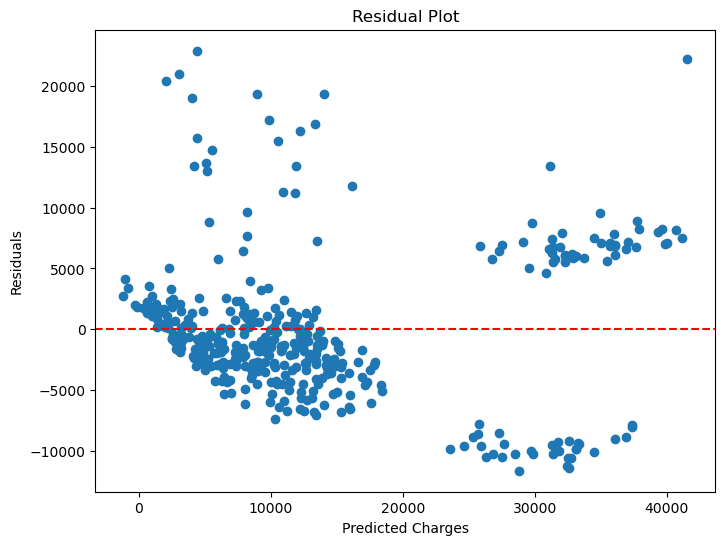

In [172]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

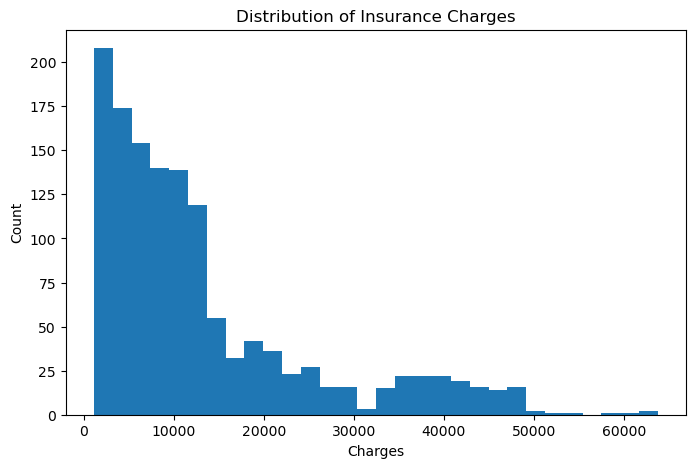

In [173]:
plt.figure(figsize=(8,5))
plt.hist(df["charges"], bins=30)
plt.xlabel("Charges")
plt.ylabel("Count")
plt.title("Distribution of Insurance Charges")
plt.show()

## Predicting Insurance Charges for New Customers

In [22]:
ages = pd.DataFrame({'age': [18, 25, 35, 45, 55, 65]})
predictions = model.predict(ages)
result = pd.DataFrame({
    'Age': ages['age'],
    'Predicted Charges': predictions})
print(result)

   Age  Predicted Charges
0   18        8011.991879
1   25        9753.545154
2   35       12241.478404
3   45       14729.411654
4   55       17217.344904
5   65       19705.278154


# Conclusion

## Single Variable Linear Regression

A Linear Regression model was trained using only the **Age** feature to predict medical insurance charges.

The model achieved a low R² score (around **0.09**), indicating that age alone is not sufficient to explain the variation in insurance charges.

This suggests that insurance charges depend on several other factors such as smoking status, BMI, sex, and region. Therefore, a single-feature model is not suitable for accurate prediction.

## Multiple Linear Regression

A Multiple Linear Regression model was trained using multiple features including **Age, BMI, Sex, and Smoker**.

The model achieved:

- Mean Absolute Error (MAE): 4207.69
- Root Mean Squared Error (RMSE): 5868.91
- R² Score: 0.765

The model explains approximately **76.5%** of the variation in insurance charges.

Compared to the single-variable model, the performance improved significantly because the model was able to learn from multiple important factors that influence insurance costs.

Overall, Multiple Linear Regression provides a much better prediction of medical insurance charges than Single Linear Regression.


# Final Comparison

| Model | R² Score | Performance |
|--------|----------|-------------|
| Single Linear Regression | 0.09 | Poor |
| Multiple Linear Regression | 0.765 | Good |

The comparison shows that using multiple relevant features significantly improves the predictive performance of the model.